<a href="https://colab.research.google.com/github/VALUESEAT/FINAL_PROJECT-semenatic-segementation/blob/main/sem_seg_proj_20233005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
=====================================================================
Semantic Segmentation with PyTorch — Pascal VOC 2012
=====================================================================
DeepLabV3-ResNet50 fine-tuned on VOC 2012 for 21-class segmentation.

How to run
----------
1. Recommended environment: Google Colab or Kaggle with GPU runtime.
   On CPU this script is impractical (each epoch can take ~30+ min).
2. First run will download VOC 2012 (~2 GB) into ./data automatically.
3. Outputs produced:
     - sample_visualization.png   (Task 1.2)

```
# This is formatted as code
```


     - training_curves.png        (Task 5.1)
     - predictions.png            (Task 5.2)
     - best_model.pth             (best checkpoint by val mIoU)



100%|██████████| 2.00G/2.00G [01:36<00:00, 20.8MB/s]


Training samples: 1464
Validation samples: 1449
Image type: <class 'PIL.Image.Image'>
Mask type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size: (500, 281)
Mask size: (500, 281)
Unique values in mask: [  0   1  15 255]


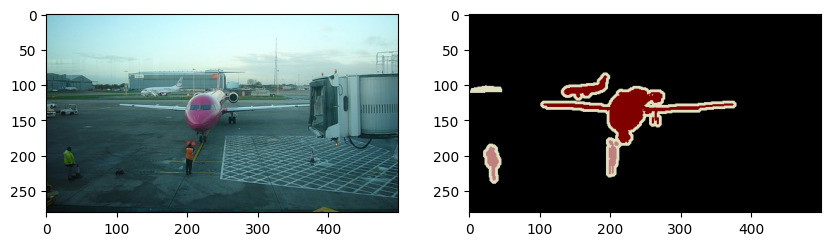

Number of unique classes in first image: 4


In [ ]:
import torch
from torchvision.datasets import VOCSegmentation
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

train_dataset = VOCSegmentation(
    root="./data", year="2012", image_set="train", download=True
)

val_dataset = VOCSegmentation(
    root="./data", year="2012", image_set="val", download=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


#  Task 1.2: Inspect a Sample
image, mask = train_dataset[0]

print(f"Image type: {type(image)}")
print(f"Mask type: {type(mask)}")
print(f"Image size: {image.size}")
print(f"Mask size: {mask.size}")
print(f"Unique values in mask: {np.unique(np.array(mask))}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(image)
ax2.imshow(mask)
plt.savefig("sample_visualization.png")
plt.show()


#  Task 1.3: Understand VOC Classes
class_names = [
    "background", "aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair",
    "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

first_mask = np.array(mask)
unique_classes = len(np.unique(first_mask))
print(f"Number of unique classes in first image: {unique_classes}")


In [ ]:

# PART 2 - CREATE DATASET WITH TRANSFORMS


from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode


# Task 2.1: Define Image and Mask Transforms
train_image_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

val_image_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor(),
])


#  Task 2.2: Implement Custom Dataset Class
class VOCDataset(Dataset):
    """Custom dataset wrapper for VOC segmentation"""

    def __init__(self, root, split='train', image_size=(256, 256), augment=True):
        self.split = split
        self.image_size = image_size
        self.augment = augment

        self.base_dataset = VOCSegmentation(
            root=root, year="2012", image_set=split, download=True
        )

        if augment:
            self.image_transform = train_image_transform
            self.mask_transform = train_mask_transform
        else:
            self.image_transform = val_image_transform
            self.mask_transform = val_mask_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]
        image = self.image_transform(image)
        mask = self.mask_transform(mask)
        # ToTensor scales mask values to [0,1]; multiply by 255 and cast
        # back to long to recover original class indices.
        mask = (mask * 255).long()
        # Remove channel dim: (1, H, W) -> (H, W)
        mask = mask.squeeze(0)
        return image, mask


train_dataset = VOCDataset(root="./data", split="train", image_size=(256, 256), augment=True)
val_dataset = VOCDataset(root="./data", split="val", image_size=(256, 256), augment=False)

sample_image, sample_mask = train_dataset[0]
print(f"Sample image shape: {sample_image.shape}")
print(f"Sample mask shape: {sample_mask.shape}")
print(f"Mask value range: {sample_mask.min()} to {sample_mask.max()}")


Sample image shape: torch.Size([3, 256, 256])
Sample mask shape: torch.Size([256, 256])
Mask value range: 0 to 255


In [ ]:
# PART 3 - BUILD MODEL


from torchvision import models
import torch.nn as nn


#  Task 3.1: Load Pre-trained Model
model = models.segmentation.deeplabv3_resnet50(pretrained=True)

# Modify classifier for 21 classes
model.classifier[4] = nn.Conv2d(256, 21, kernel_size=1)
# Auxiliary classifier must also be replaced or training will crash
# with a channel-mismatch error.
model.aux_classifier[4] = nn.Conv2d(256, 21, kernel_size=1)

fcn_model = models.segmentation.fcn_resnet50(pretrained=True)

print(f"DeepLabV3 parameters: {sum(p.numel() for p in model.parameters())}")
print(f"FCN parameters: {sum(p.numel() for p in fcn_model.parameters())}")


#  Task 3.2: Setup Training Components
from torch.utils.data import DataLoader
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


# Task 3.3: Implement Metrics
def compute_pixel_accuracy(pred, target):
    return ((pred == target).sum() / target.numel()).item()


def compute_miou(pred, target, num_classes=21):
    ious = []
    for c in range(num_classes):
        intersection = ((pred == c) & (target == c)).sum().float()
        union = ((pred == c) | (target == c)).sum().float()
        if union == 0:
            continue
        iou = intersection / union
        ious.append(iou.item())
    return sum(ious) / len(ious) if ious else 0.0


dummy_pred = torch.randint(0, 21, (4, 256, 256))
dummy_target = torch.randint(0, 21, (4, 256, 256))
acc = compute_pixel_accuracy(dummy_pred, dummy_target)
miou = compute_miou(dummy_pred, dummy_target)
print(f"Test accuracy: {acc:.4f}")
print(f"Test mIoU: {miou:.4f}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 168MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 177MB/s]


DeepLabV3 parameters: 42004074
FCN parameters: 35322218
Test accuracy: 0.0473
Test mIoU: 0.0242


In [ ]:
 # Task 4.1: Implement Training Functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch_idx, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"  Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_acc = 0
    total_miou = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)

            preds = outputs.argmax(dim=1)

            total_loss += loss.item()
            total_acc += compute_pixel_accuracy(preds.cpu(), masks.cpu())
            total_miou += compute_miou(preds.cpu(), masks.cpu())

    return total_loss / len(loader), total_acc / len(loader), total_miou / len(loader)


#  Task 4.2: Complete Training Loop
num_epochs = 30
best_val_miou = 0.0

train_losses = []
val_losses = []
val_mious = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 40)

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_miou = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mious.append(val_miou)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val mIoU: {val_miou:.4f}")

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  New best model saved! (mIoU: {val_miou:.4f})")

print(f"\nTraining complete! Best validation mIoU: {best_val_miou:.4f}")



Epoch 1/30
----------------------------------------
  Batch 0/183, Loss: 3.0165
  Batch 20/183, Loss: 0.5188
  Batch 40/183, Loss: 1.6079
  Batch 60/183, Loss: 0.6444
  Batch 80/183, Loss: 0.4392
  Batch 100/183, Loss: 0.6022
  Batch 120/183, Loss: 0.5417
  Batch 140/183, Loss: 0.5731
  Batch 160/183, Loss: 0.6931
  Batch 180/183, Loss: 0.5454
Train Loss: 0.7567
Val Loss: 0.4116, Val Acc: 0.8372, Val mIoU: 0.3978
  New best model saved! (mIoU: 0.3978)

Epoch 2/30
----------------------------------------
  Batch 0/183, Loss: 0.3681
  Batch 20/183, Loss: 0.5239
  Batch 40/183, Loss: 0.2809
  Batch 60/183, Loss: 0.4591
  Batch 80/183, Loss: 0.3490
  Batch 100/183, Loss: 0.2693
  Batch 120/183, Loss: 0.5387
  Batch 140/183, Loss: 0.4005
  Batch 160/183, Loss: 0.5121
  Batch 180/183, Loss: 0.8297
Train Loss: 0.3980
Val Loss: 0.4920, Val Acc: 0.8040, Val mIoU: 0.3369

Epoch 3/30
----------------------------------------
  Batch 0/183, Loss: 0.4256
  Batch 20/183, Loss: 0.1746
  Batch 40/183,

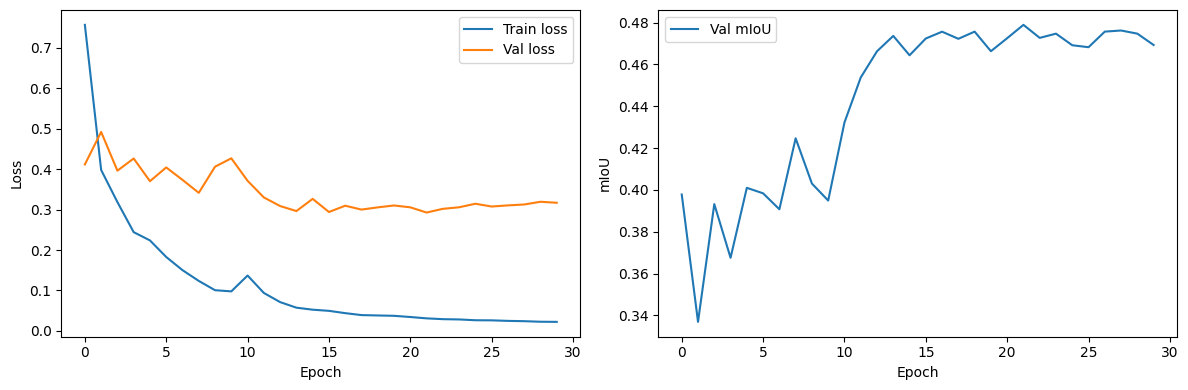

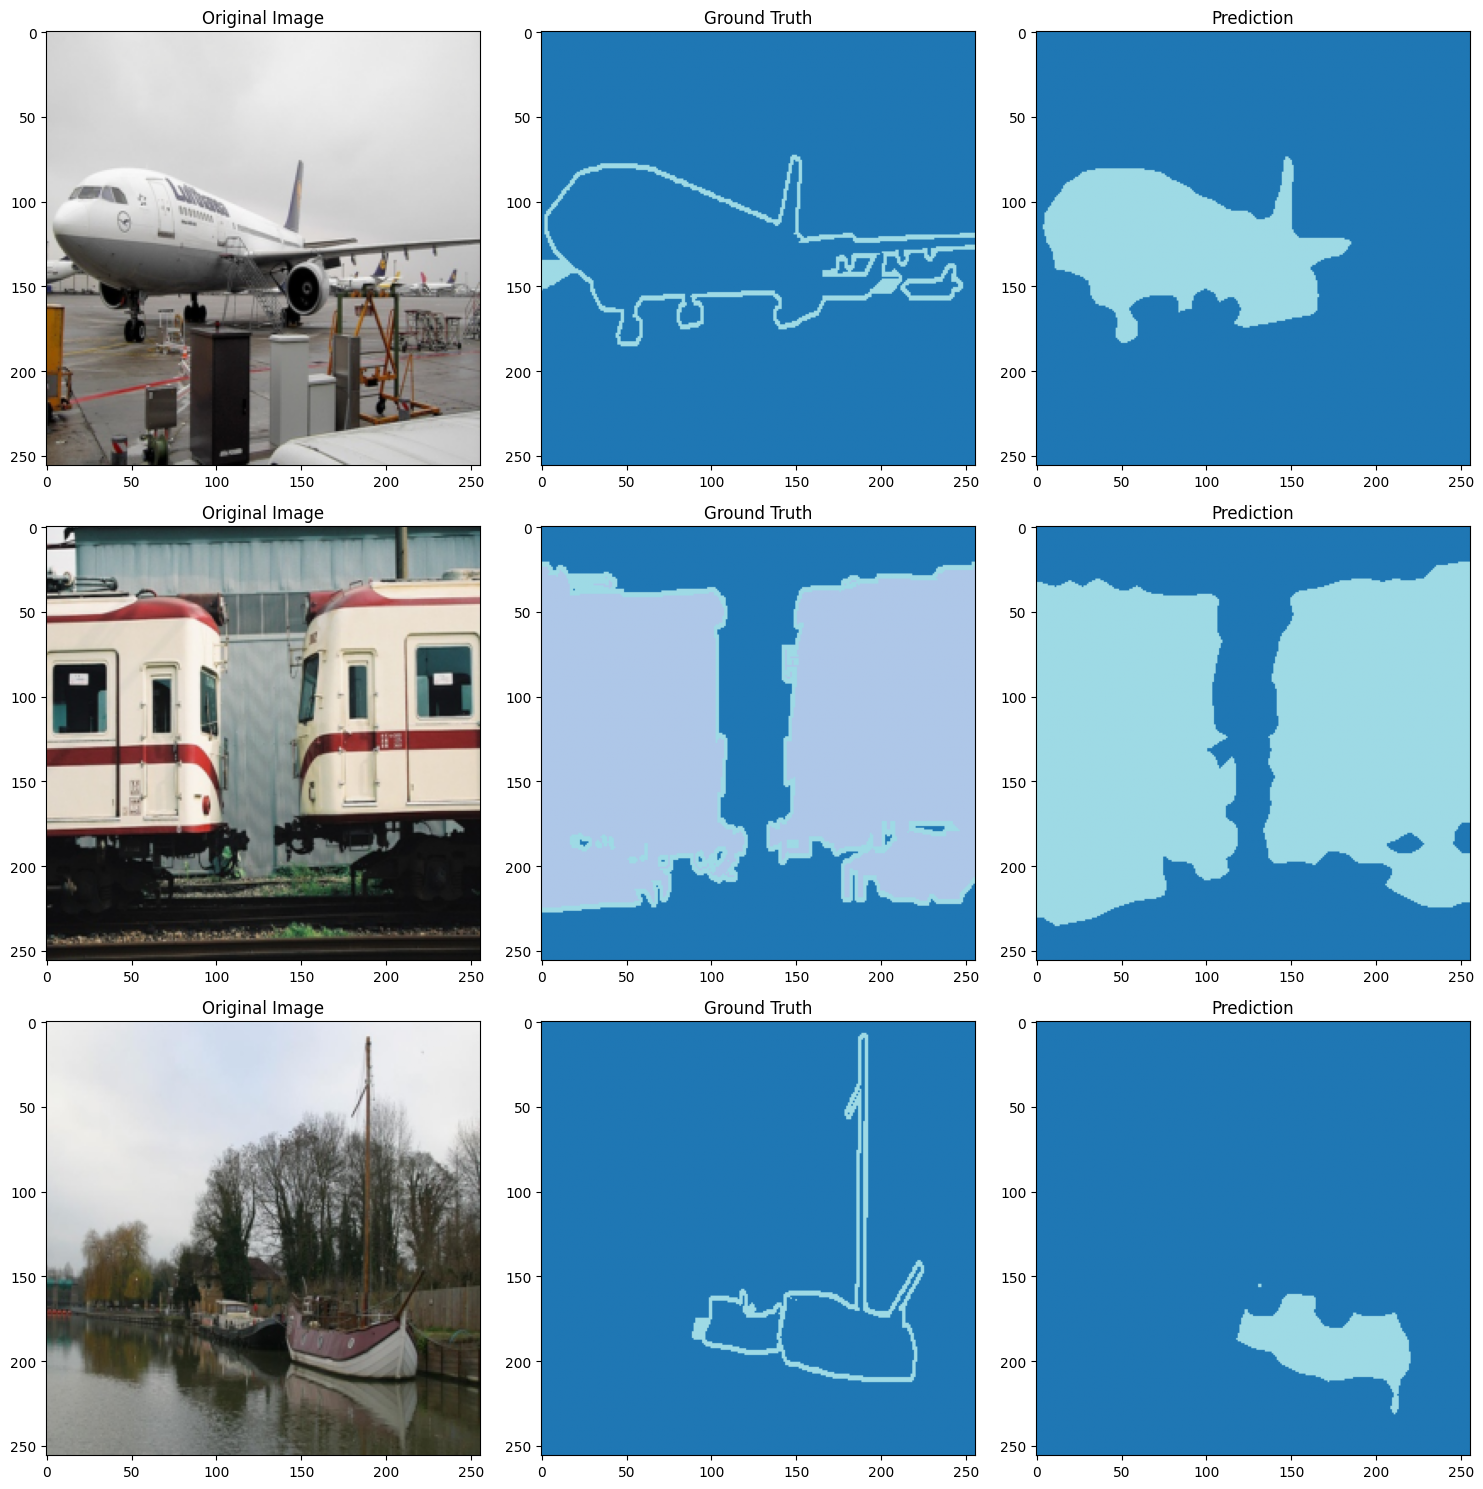

background: 0.8908
aeroplane: 0.7363
bicycle: 0.3530
bird: 0.6858
boat: 0.5878
bottle: 0.5619
bus: 0.8625
car: 0.7678
cat: 0.7201
chair: 0.2292
cow: 0.6672
diningtable: 0.4980
dog: 0.6489
horse: 0.6194
motorbike: 0.6474
person: 0.7377
pottedplant: 0.4382
sheep: 0.6032
sofa: 0.3635
train: 0.7406
tvmonitor: 0.6626

Best performing class: background (0.8908)
Worst performing class: chair (0.2292)


In [ ]:
# Task 5.1: Plot Training Curves
def plot_training_curves(train_losses, val_losses, val_mious):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses, label="Train loss")
    ax1.plot(val_losses, label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(val_mious, label="Val mIoU")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("mIoU")
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()


plot_training_curves(train_losses, val_losses, val_mious)


# Task 5.2: Visualize Predictions
def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        image, mask = dataset[i]

        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)['out']
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()

        # Denormalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = (image * std + mean).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title("Original Image")
        axes[i, 1].imshow(mask, cmap='tab20')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(pred, cmap='tab20')
        axes[i, 2].set_title("Prediction")

    plt.tight_layout()
    plt.savefig('predictions.png')
    plt.show()


visualize_predictions(model, val_dataset, device, num_samples=3)


#  Task 5.3: Analyze Class Performance
def compute_class_iou(model, loader, device, num_classes=21):
    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)

    model.eval()
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']
            preds = outputs.argmax(dim=1)

            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)
                intersection[c] += (pred_c & mask_c).sum().cpu().float()
                union[c] += (pred_c | mask_c).sum().cpu().float()

    ious = intersection / (union + 1e-10)
    return ious


class_ious = compute_class_iou(model, val_loader, device)

for i, iou in enumerate(class_ious):
    print(f"{class_names[i]}: {iou:.4f}")

best_class_idx = torch.argmax(class_ious).item()
worst_class_idx = torch.argmin(class_ious).item()
print(f"\nBest performing class: {class_names[best_class_idx]} ({class_ious[best_class_idx]:.4f})")
print(f"Worst performing class: {class_names[worst_class_idx]} ({class_ious[worst_class_idx]:.4f})")

QUESTION 1: Why do we use ignore_index=255 in CrossEntropyLoss?
ANSWER:
VOC marks ambiguous boundary pixels (where it is unclear whether they
belong to the object or background) with the value 255 instead of a
real class index. Setting ignore_index=255 tells the loss to skip these
pixels entirely, so the model is neither rewarded nor penalized for its
predictions on uncertain ground-truth regions. Without this, the loss
would crash trying to index a 21-channel output with index 255.

QUESTION 2: Why use bilinear interpolation for images but nearest
neighbor for masks?
ANSWER:
Image pixel values are continuous color intensities, so averaging
neighbors with bilinear interpolation produces smooth, plausible
results. Mask pixel values are categorical class indices (0, 1, 2...),
which are NOT continuous. Bilinear interpolation on a mask would
average class 1 (aeroplane) with class 12 (dog) to get 6.5, which
rounds to class 6 or 7 (bus or car) - inventing objects that do not
exist. Nearest-neighbor copies the closest existing label, preserving
class integrity exactly.

QUESTION 3: What is the difference between FCN and DeepLabV3 architectures?
ANSWER:
Both convert a classification CNN (ResNet50) into a per-pixel classifier,
but they handle the resolution-vs-semantics tradeoff differently. FCN
uses transposed convolutions and skip connections from earlier layers
to upsample low-resolution predictions back to image size; this works
but produces blurry boundaries. DeepLabV3 uses atrous (dilated)
convolutions to expand the receptive field WITHOUT downsampling, so
spatial resolution is preserved through the deep layers. It also adds
the ASPP module (Atrous Spatial Pyramid Pooling), which applies several
parallel atrous convolutions at different dilation rates to capture
multi-scale context simultaneously. DeepLabV3 typically gives sharper
boundaries and higher accuracy.

QUESTION 4: Why do we normalize images with mean=[0.485,0.456,0.406]
and std=[0.229,0.224,0.225]?
ANSWER:
These are the per-channel mean and standard deviation of the ImageNet
training set, the dataset on which the ResNet50 backbone was originally
pretrained. The pretrained weights expect inputs that follow this
distribution (zero mean, unit variance per channel). Normalizing with
these specific values matches the input distribution the backbone was
trained on, allowing the learned features to transfer cleanly to the
segmentation task.

QUESTION 5: What is mIoU and why is it preferred over pixel accuracy
for segmentation?
ANSWER:
Pixel accuracy is the fraction of correctly classified pixels. The
problem: in VOC, ~70-90% of pixels are background, so a model that
predicts "background everywhere" trivially gets very high accuracy
while detecting nothing useful. IoU (Intersection over Union) measures
overlap per class: |predicted INTERSECT true| / |predicted UNION true|.
A "background-only" model gets IoU = 0 for every object class.
mIoU averages IoU across all 21 classes, so each class contributes
equally regardless of size. This exposes models that ignore rare
classes, while pixel accuracy hides them. mIoU is the standard
benchmark metric for semantic segmentation.
"""